This is a compilation of examples of uses of RSRS

In [14]:
from rsrs_config import RSRSBenchmarkConfig
import numpy as np
print(RSRSBenchmarkConfig.__init__.__doc__)


        Initialize RSRS Benchmark Configuration.

        Parameters
        ----------
        operator_type : int, optional
            Index selecting the structured operator type to use.
            Options include:
            0: BasicStructuredOperator (default)
            1: BemppClLaplaceSingleLayer
            2: BemppClHelmholtzSingleLayer
            3: KiFMMLaplaceOperator
            4: KiFMMHelmholtzOperator
            5: BemppRsLaplaceOperator
            6: BemppClLaplaceSingleLayerModified
            The choice affects the problem type and required parameters and more kernels can be addded in python/structured_operators.py

        precision : int, optional
            Index for numerical precision:
            0: Single precision (not fully enabled)
            1: Double precision (default)

        h : float, optional
            Characteristic meshwidth used in spatial discretization.
            For some dimension argument types, this can be computed internally

In [34]:
## Generate the test case either to run the test or retrieve results
## recommendations: if operator_type = 5, and if ref_level = 8, pick depth = 4 (this is a problem of around 500k dofs)
## if ref_level = 9, pick depth = 5 (this is a problem of around 2MM dofs)
config = RSRSBenchmarkConfig(operator_type=5, dim_arg_type=3, ref_level=0.05, depth=3, min_level = 1, factors_cn = True, max_tree_depth=4)

In [35]:
## Generate the shell script (disable it unless you want to run the test)
config.generate_bash_script("run_test.sh")

python(75564) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [4]:
## Running test in Rust

#!./run_test.sh

In [4]:
print("This problem has " + str(config.get_degrees_of_freedom()) + " degrees of freedom")

This problem has 32768 degrees of freedom


In [5]:
print(config.plot_errors_vs_tolerance.__doc__)


        Plot a specified error metric vs tolerance.

        Parameters
        ----------
        metric_index : int
            The index of the error metric to plot on the y-axis. Must be one of:
            1 - 'norm_2_error'
            2 - 'norm_2_error_inv'
            3 - 'app_condition_number'
            4 - 'tot_num_samples'
            5 - 'residual_size'
        logx : bool
            If True, use logarithmic scale for the x-axis (tolerance).
        logy : bool
            If True, use logarithmic scale for the y-axis (metric).

        Raises
        ------
        ValueError
            If `metric_index` is not in the range 1 to 5.
        


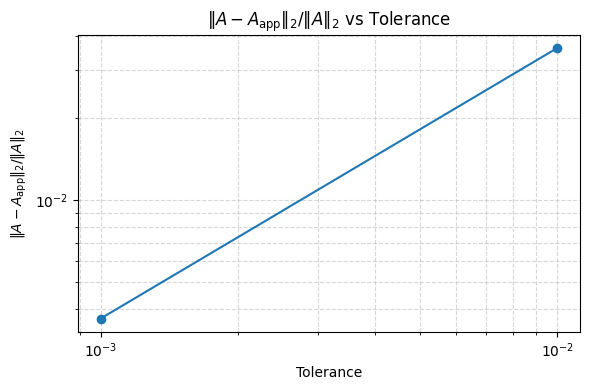

In [6]:
config.plot_errors_vs_tolerance(1, save_plot=True)

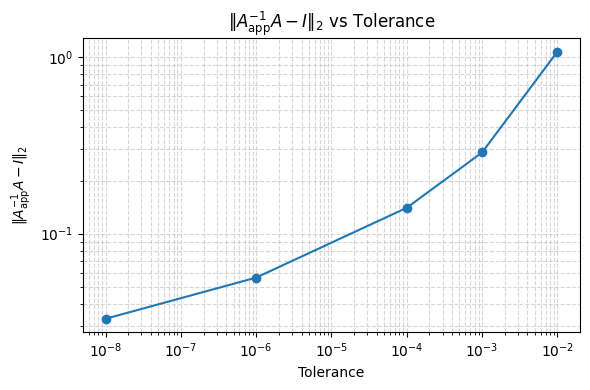

In [8]:
config.plot_errors_vs_tolerance(2)

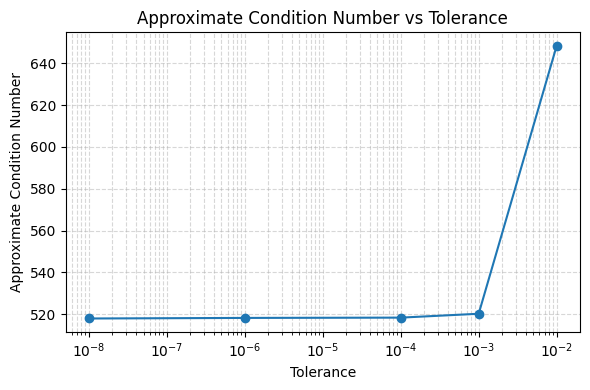

In [9]:
config.plot_errors_vs_tolerance(3, logy=False)

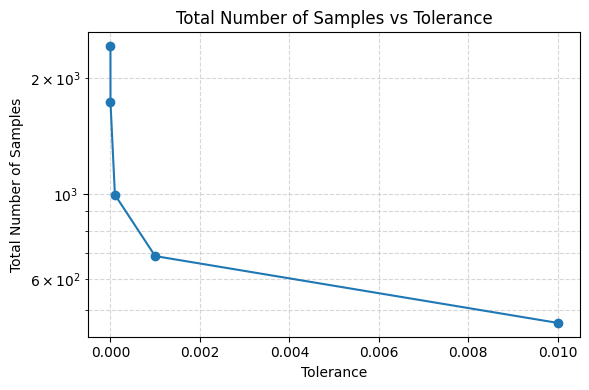

In [10]:
config.plot_errors_vs_tolerance(4, False)

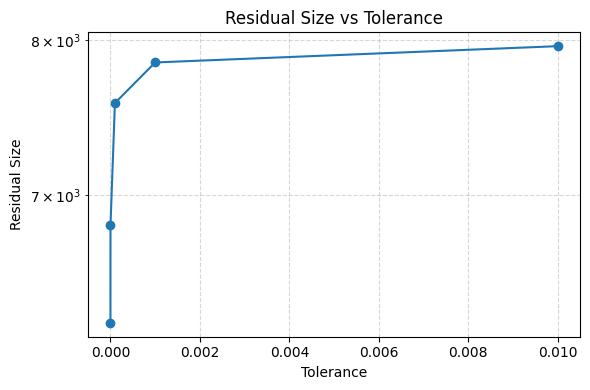

In [11]:
config.plot_errors_vs_tolerance(5, False)

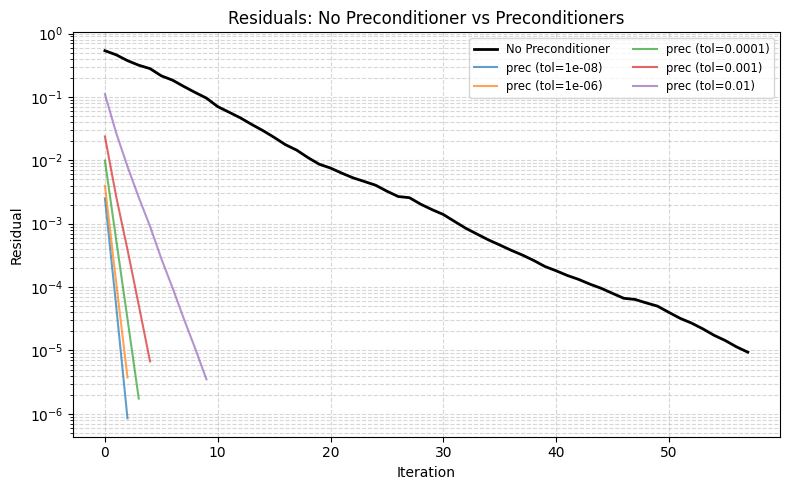

In [12]:
config.plot_gmres_residuals()

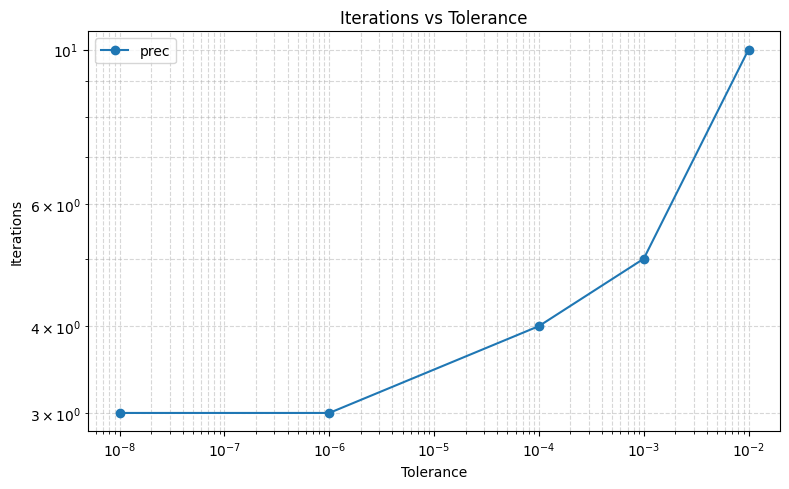

In [13]:
config.plot_residual_convergence()

In [14]:
print(config.plot_total_elapsed_time_vs_tolerance.__doc__)


        Plot total elapsed time without sampling vs tolerance (in seconds).

        Parameters
        ----------
        logx : bool, optional
            If True, use log scale on the x-axis (tolerance).
        logy : bool, optional
            If True, use log scale on the y-axis (time).
        


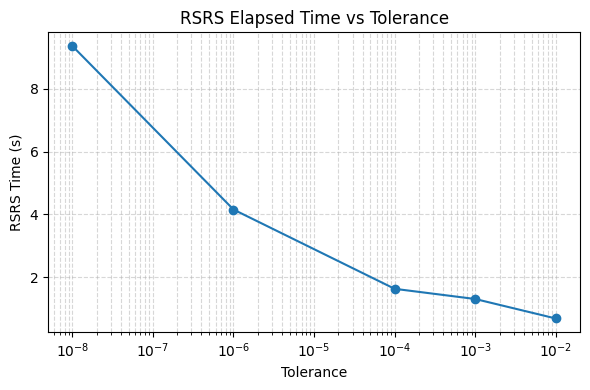

In [15]:
config.plot_total_elapsed_time_vs_tolerance(logy=False)

In [16]:
print(config.plot_time_breakdown_piecharts.__doc__)


        Plot a pie chart of time breakdown for each tolerance.

        Parameters
        ----------
        max_charts : int or None
            Maximum number of pie charts to display. If None, shows all.
        


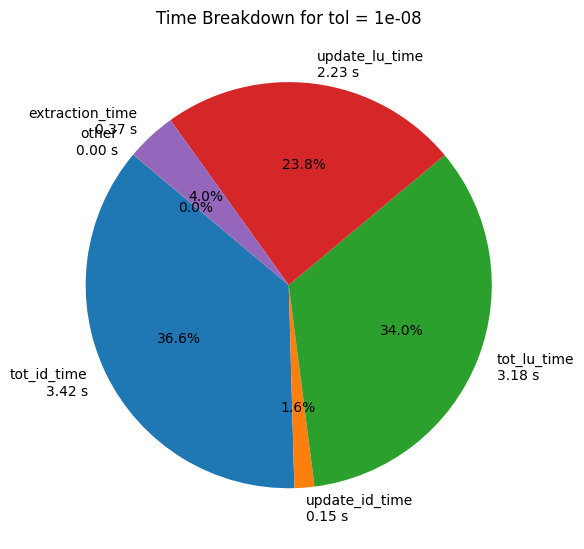

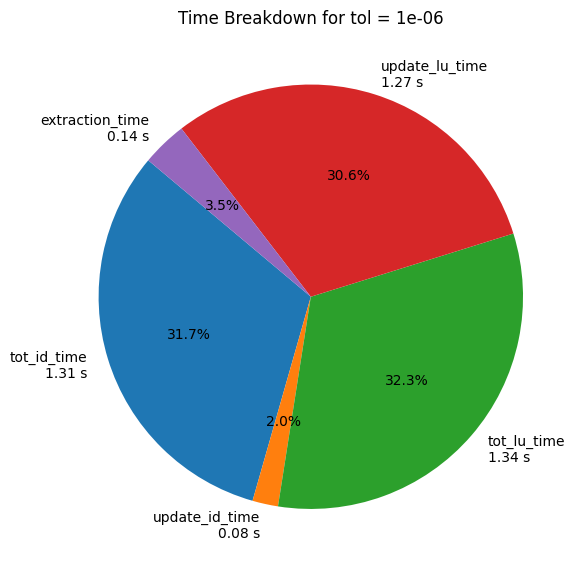

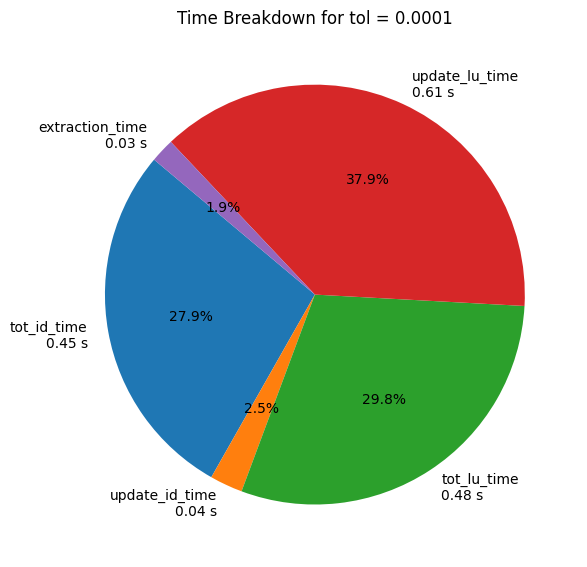

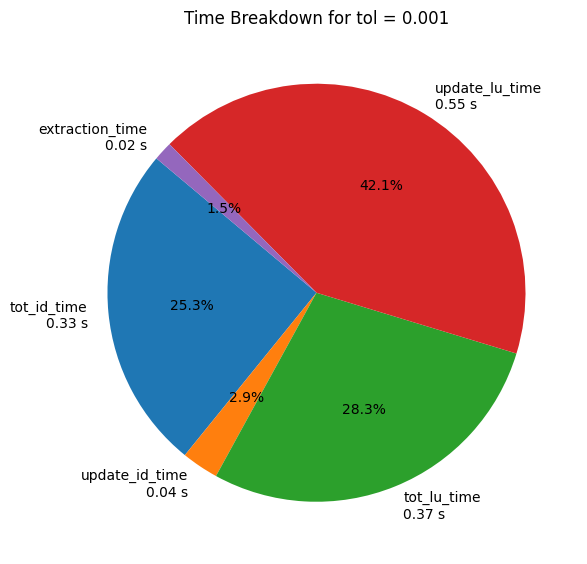

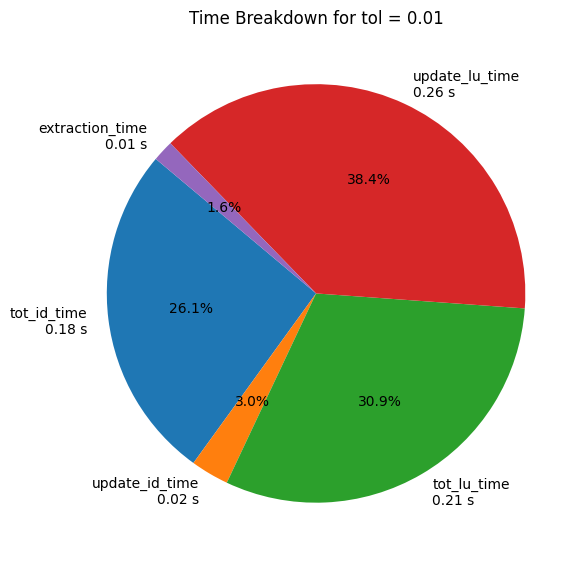

In [17]:
config.plot_time_breakdown_piecharts()

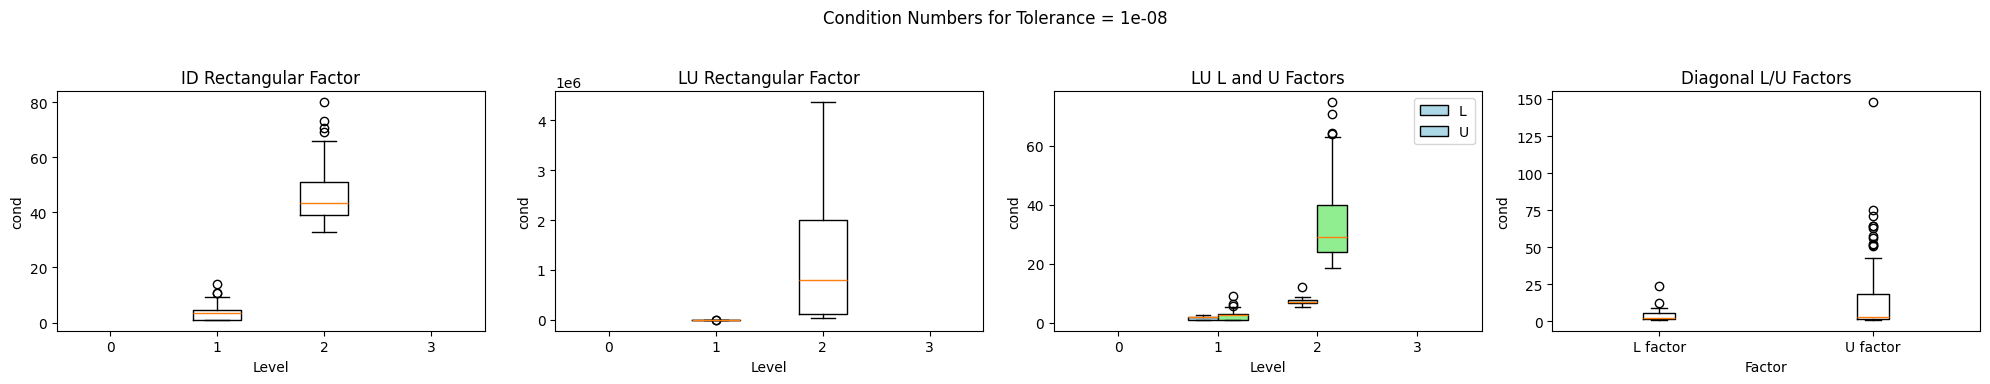

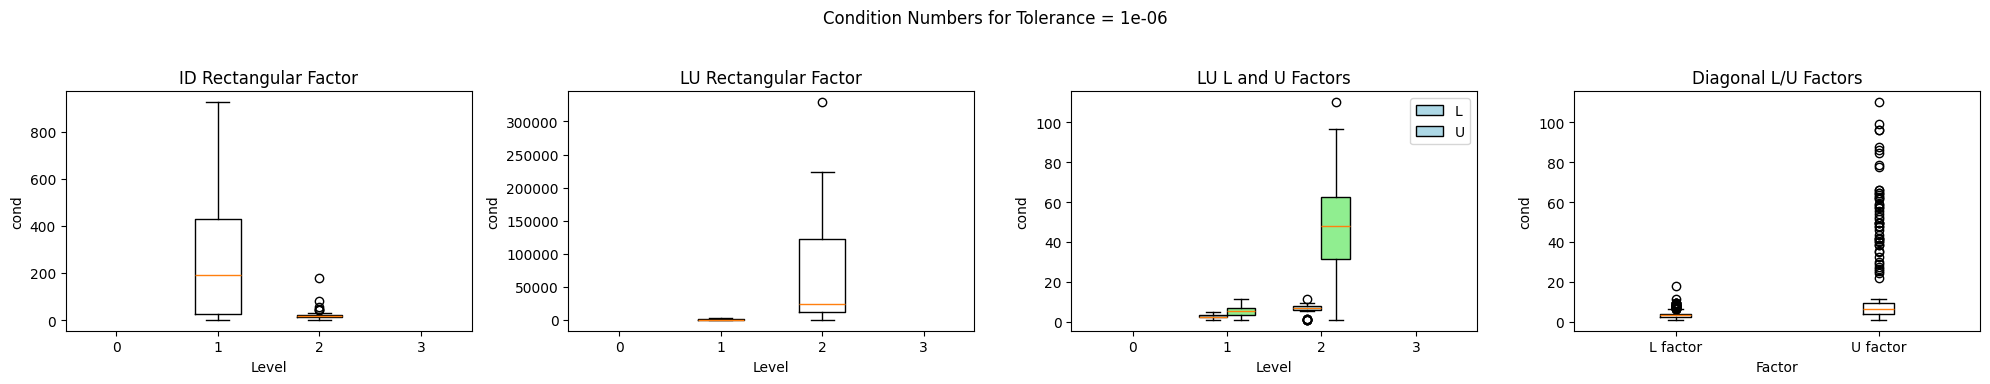

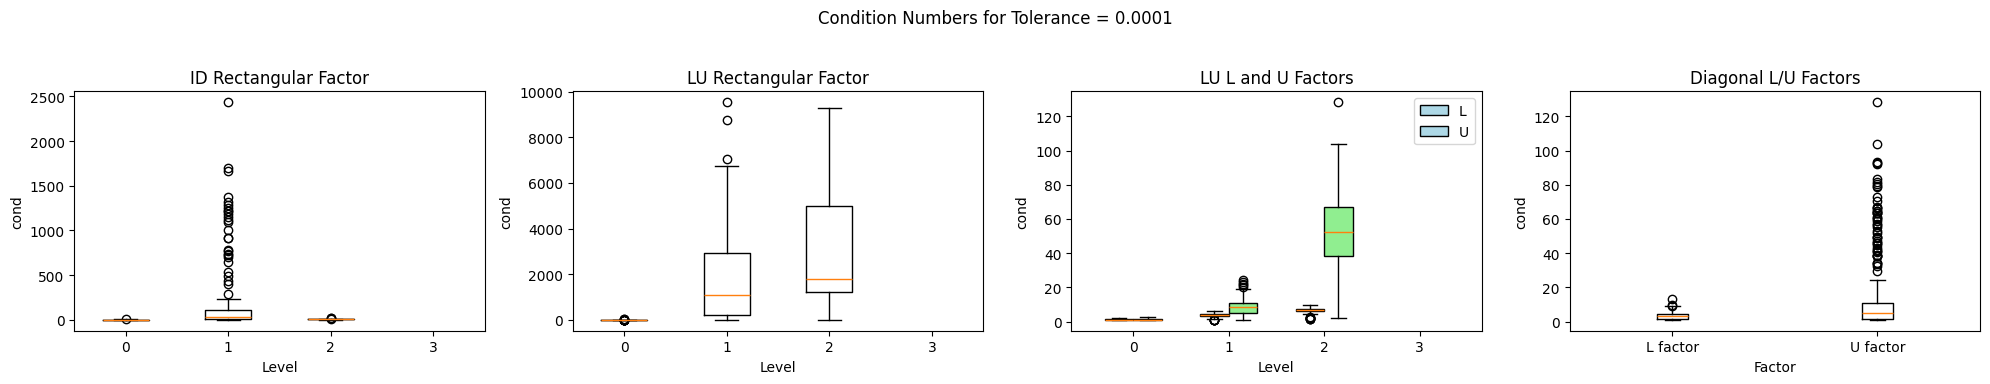

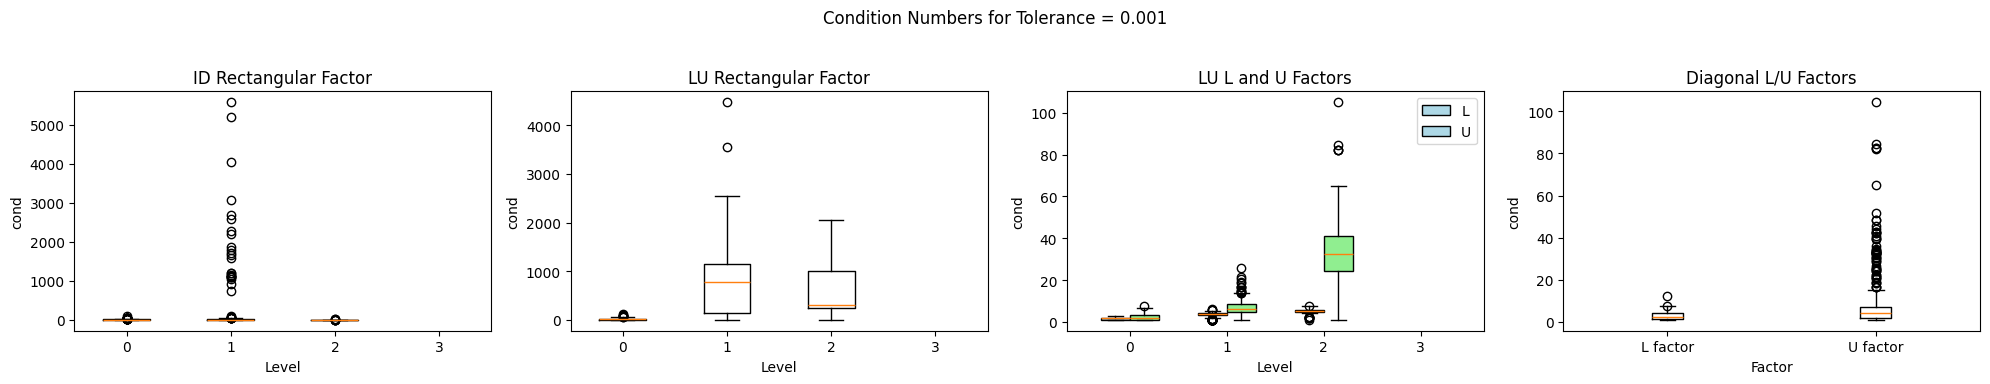

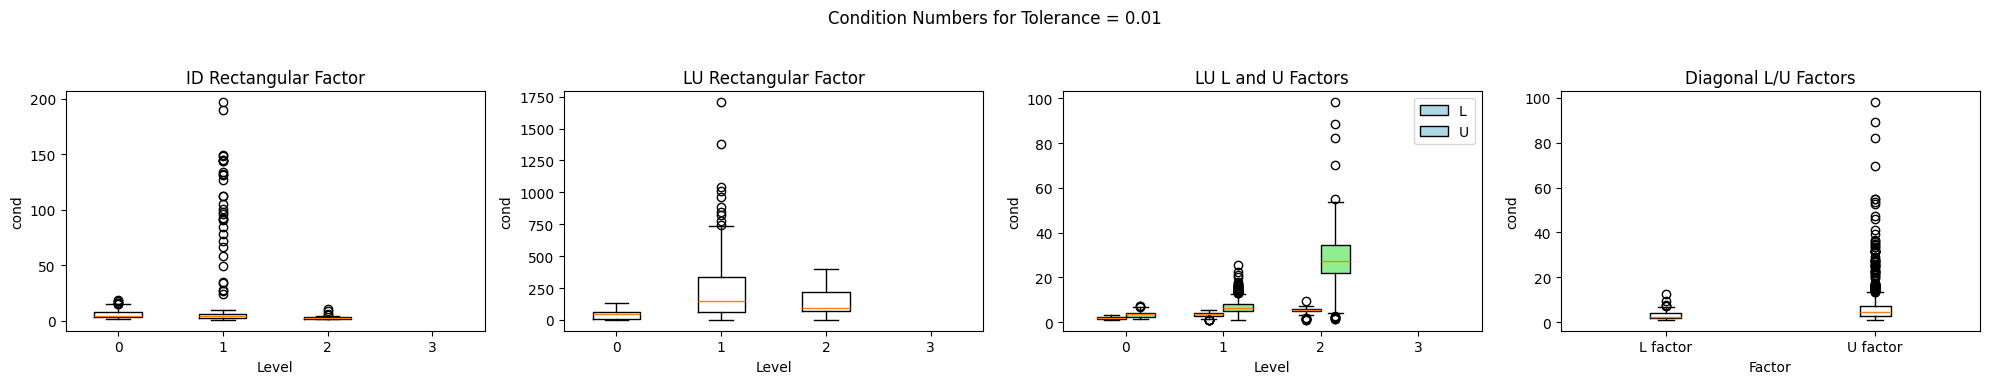

In [18]:
config.plot_condition_numbers()

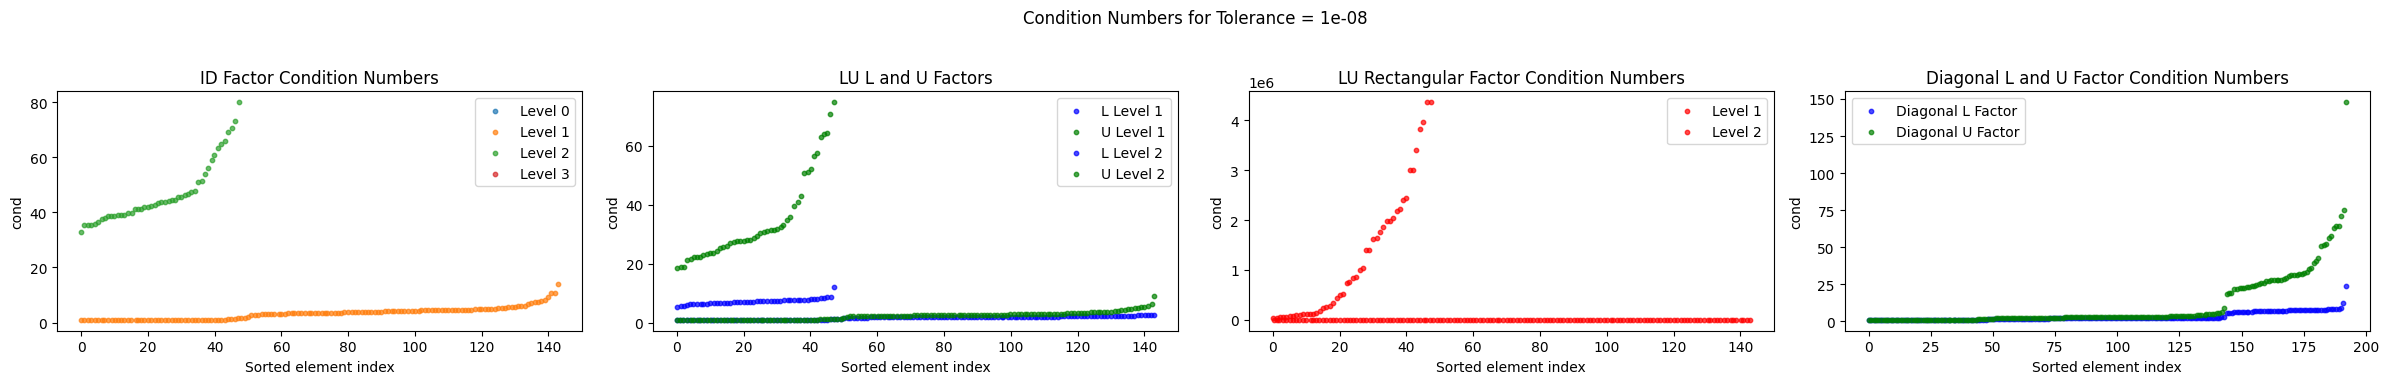

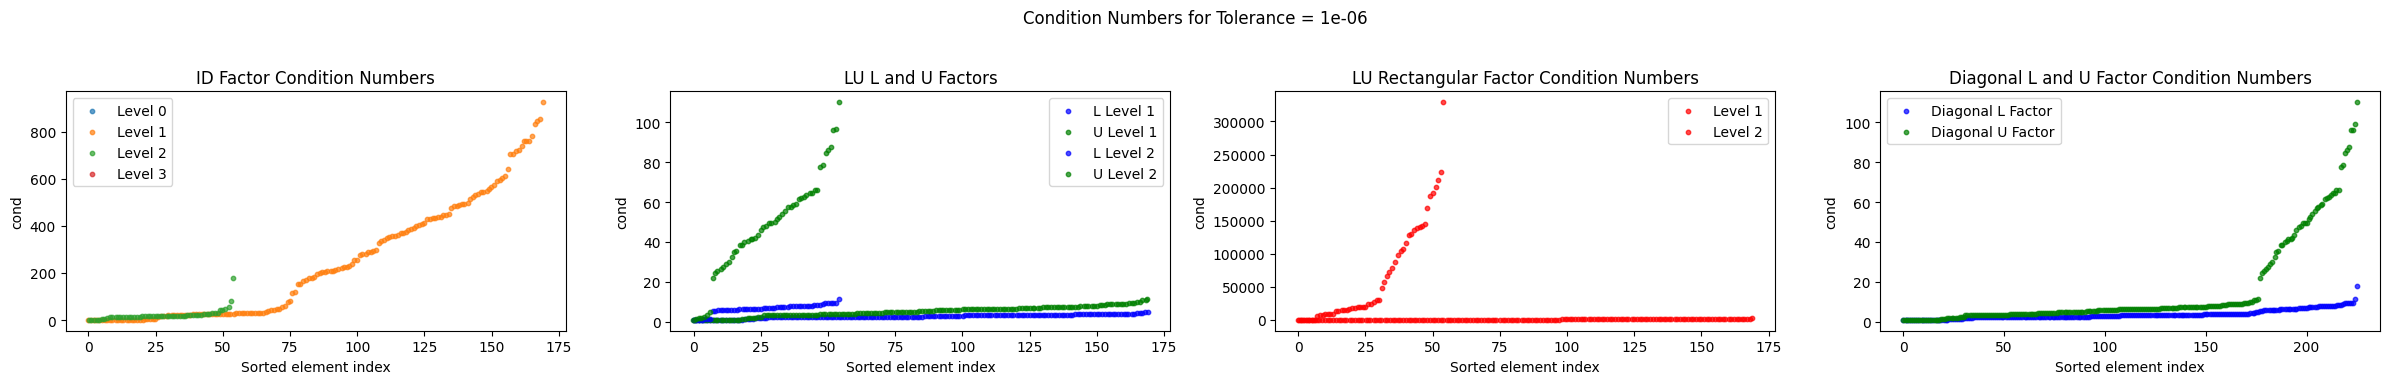

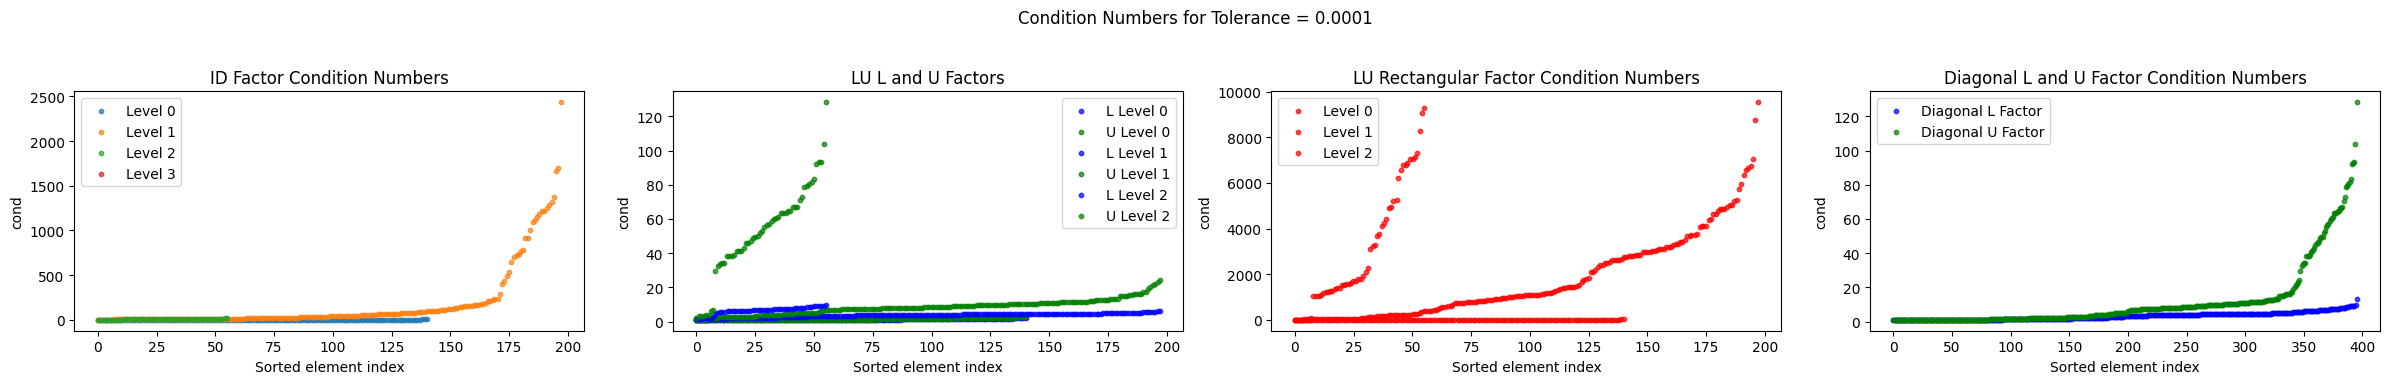

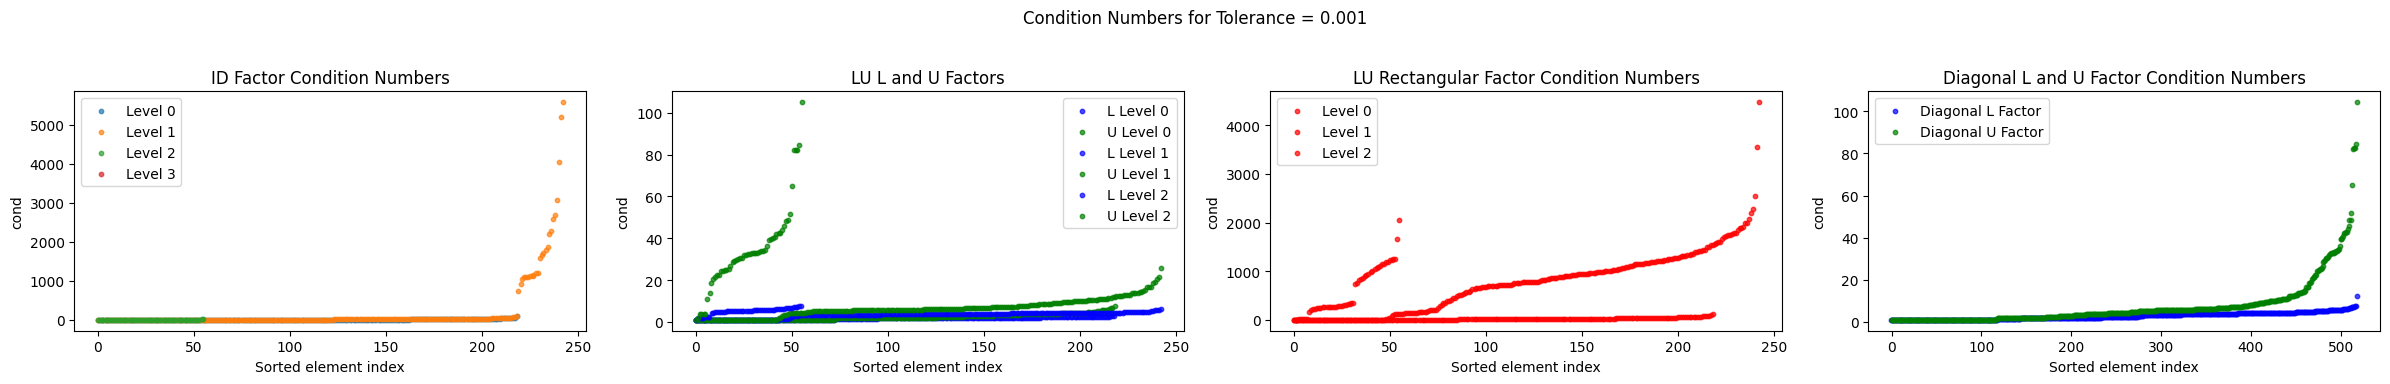

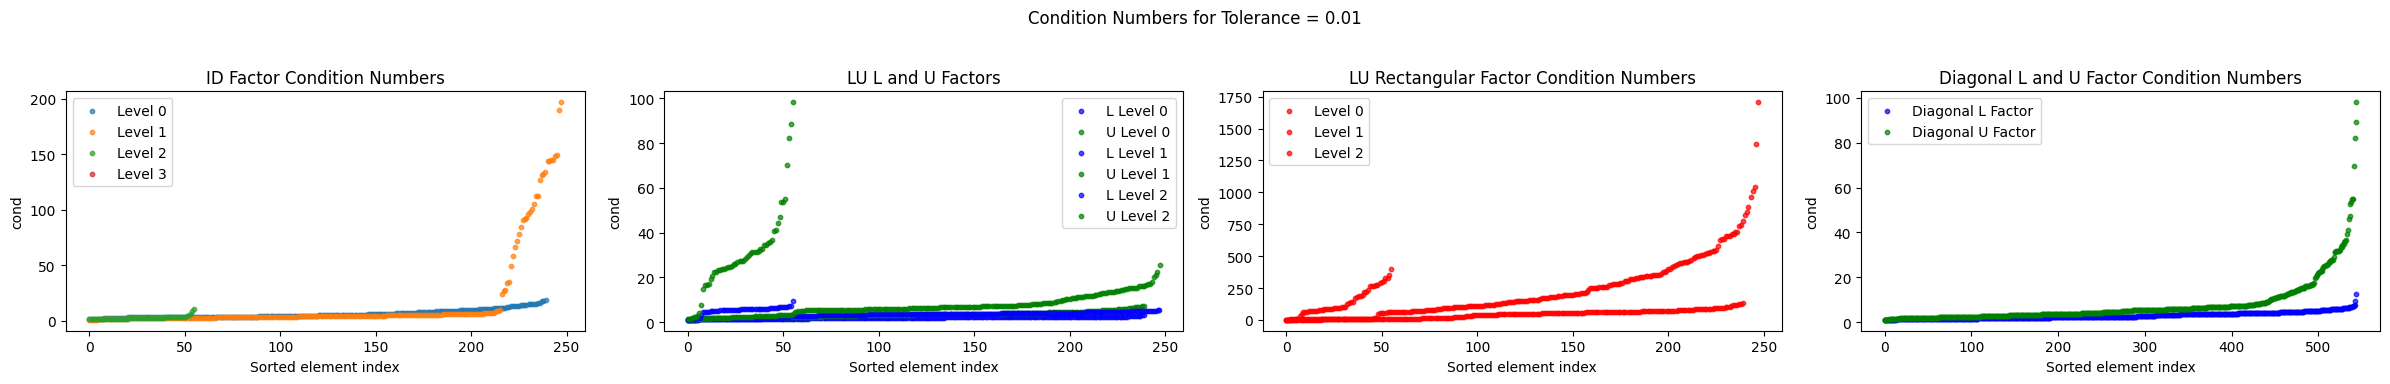

In [19]:
config.plot_condition_numbers_scatter()

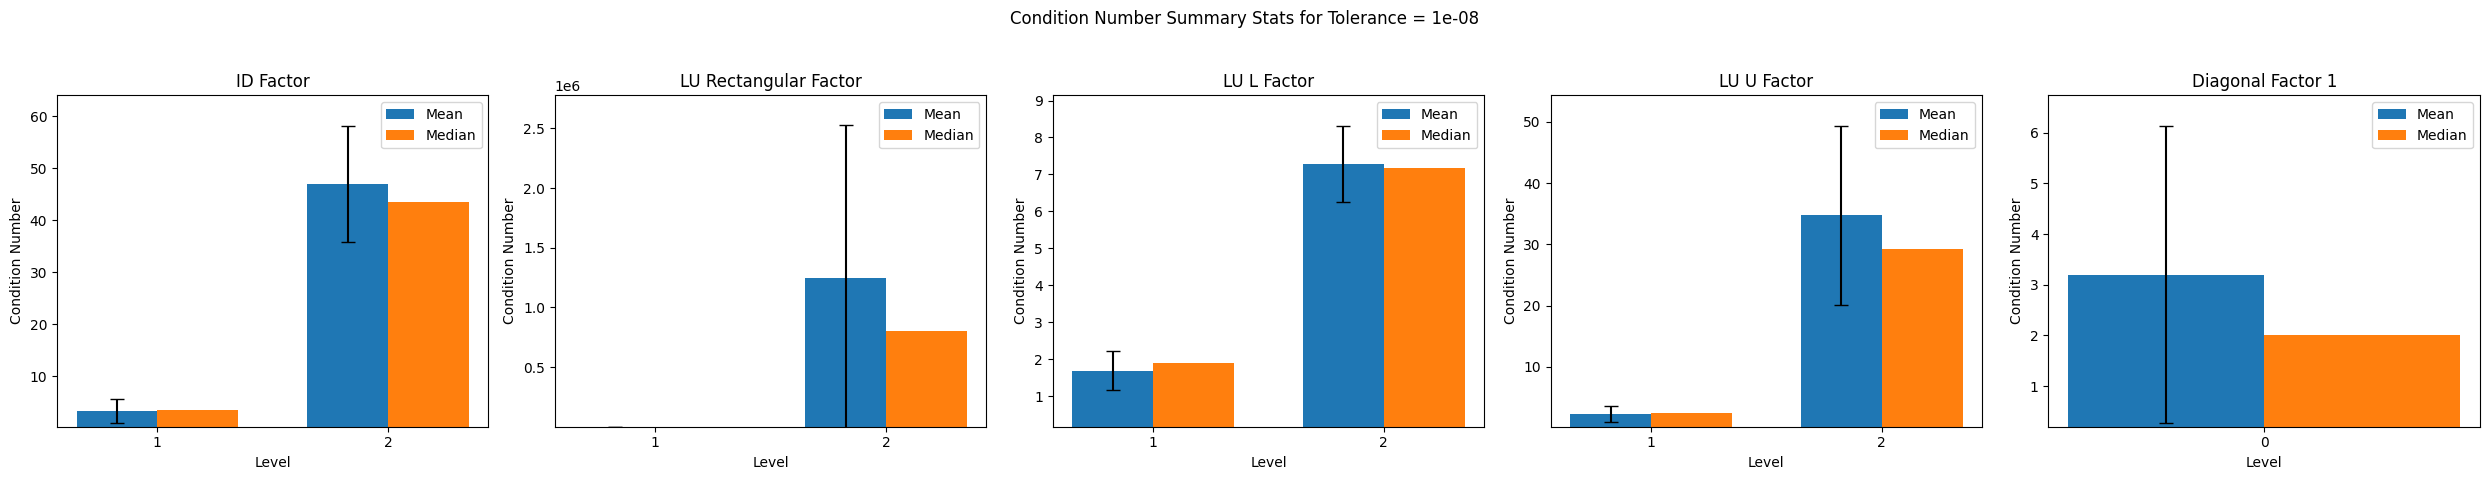

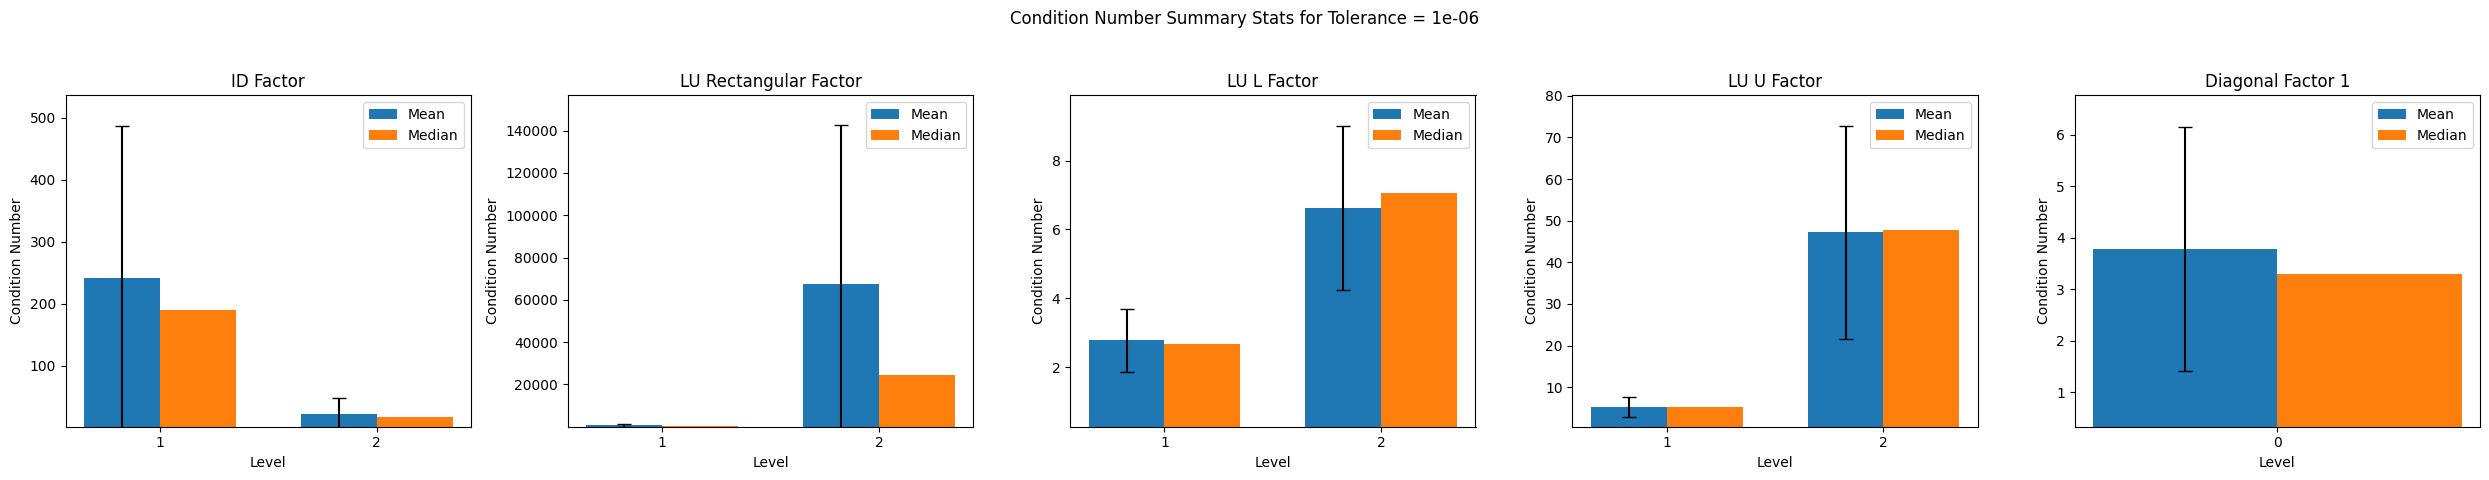

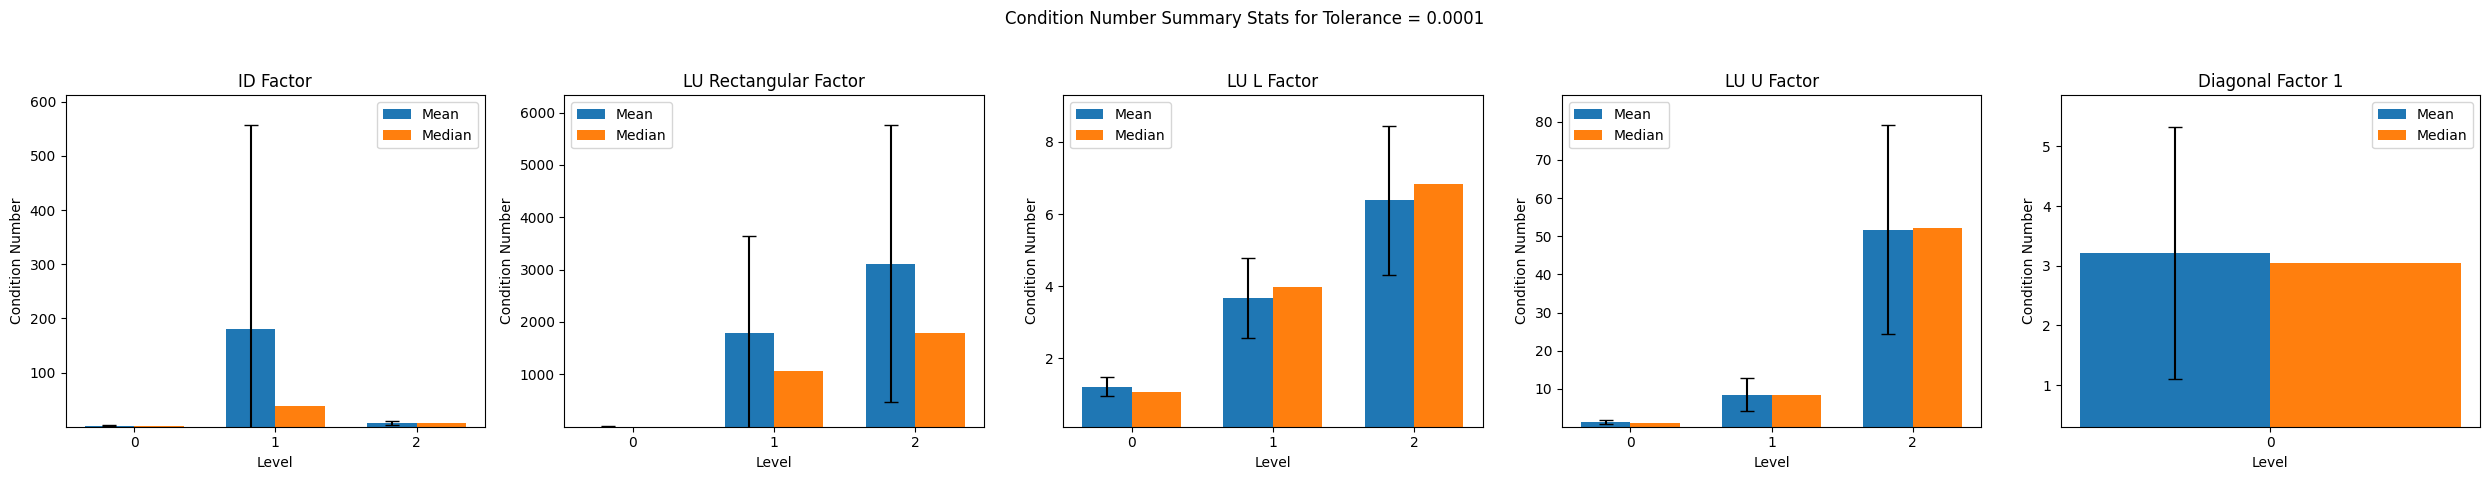

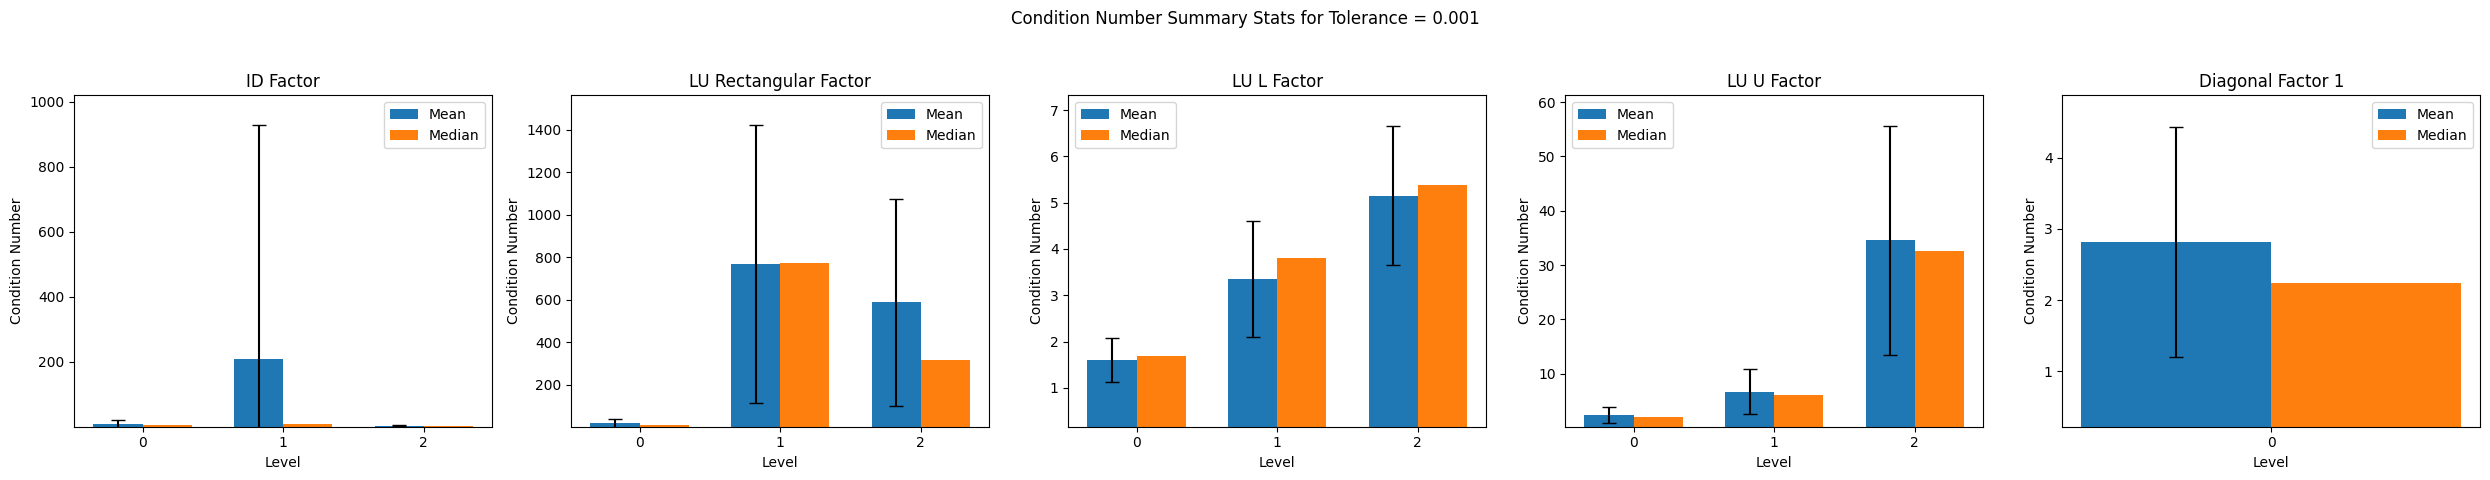

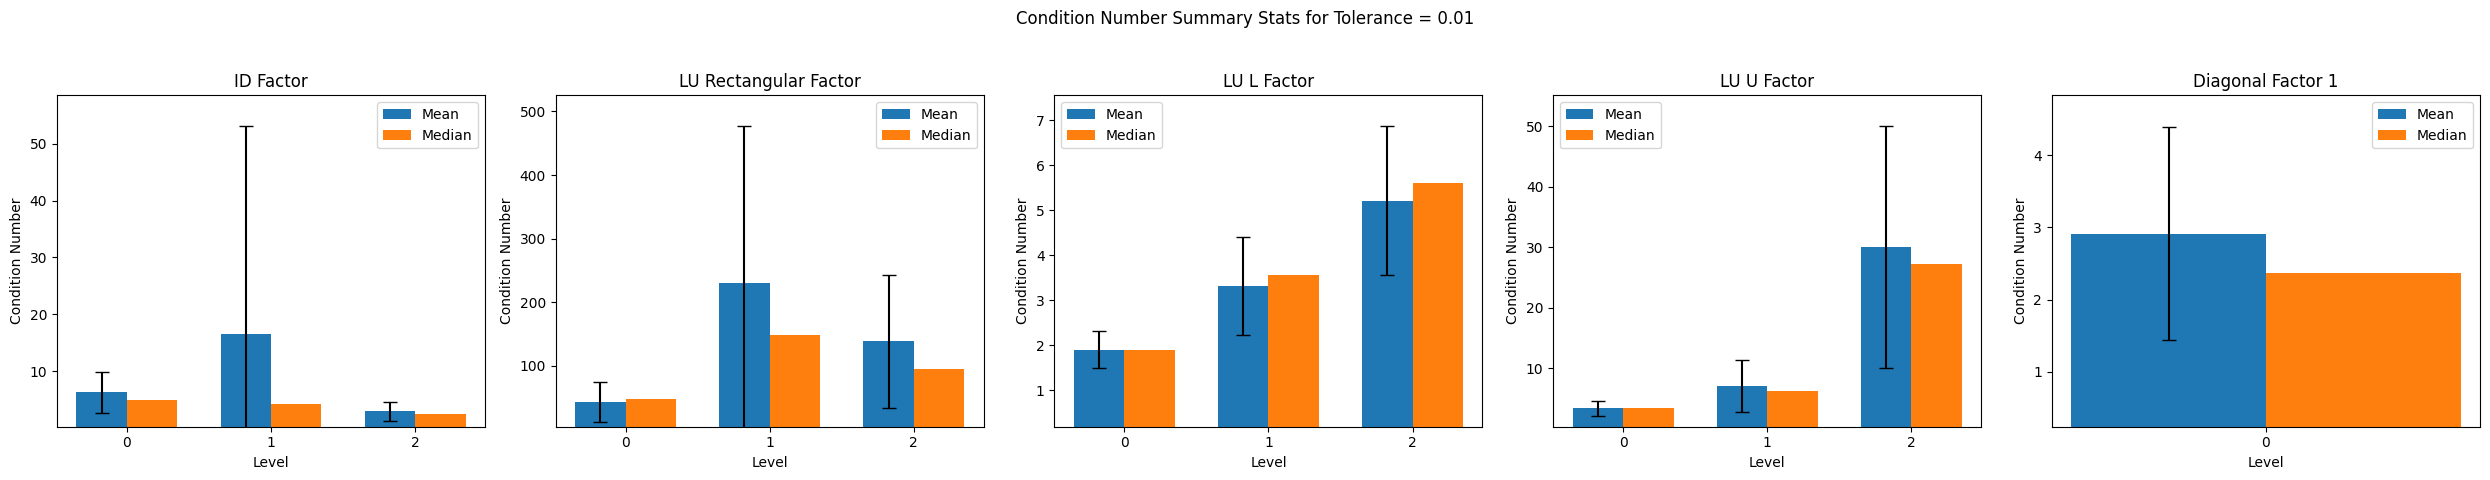

In [20]:
config.plot_condition_number_summaries()